In [ ]:
# load library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from sklearn.decomposition import PCA
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from sklearn.model_selection import train_test_split

In [ ]:
#load dataset
file_path = r"~\cards.csv"

df = pd.read_csv(file_path)

print("Shape data train:", df.shape)
print("Shape label train:", df.labels.shape)

Shape data train: (8155, 5)
Shape label train: (8155,)


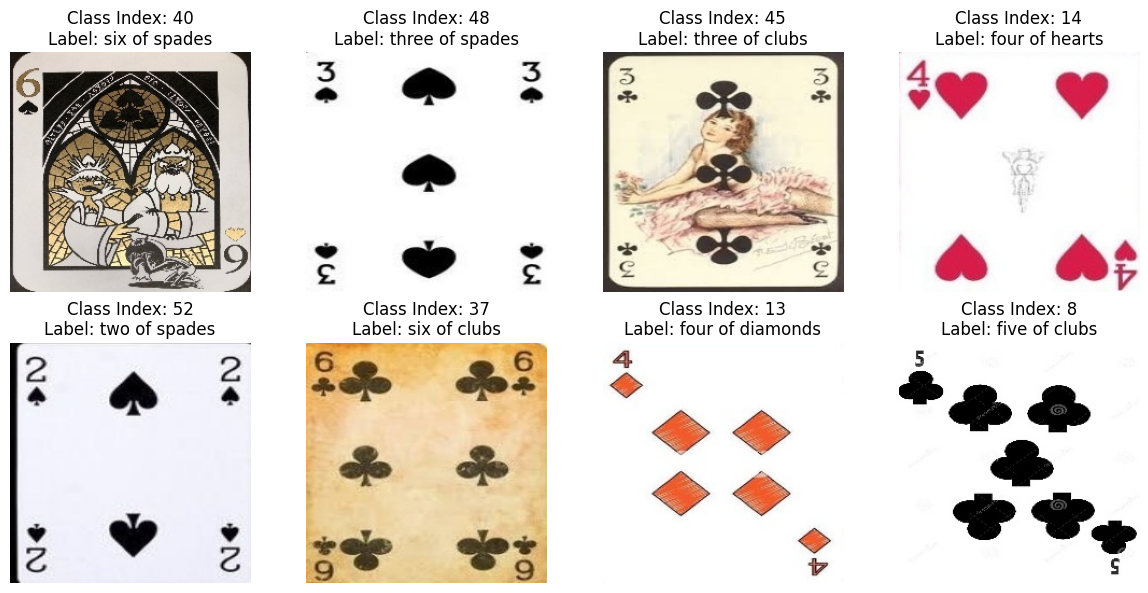

In [22]:
#viasualisasi citra
df_random_unique = df.sample(frac=1).drop_duplicates(subset=['labels'])

num_to_show = 8
plt.figure(figsize=(12, 6))

for i in range(num_to_show):
    plt.subplot(2, 4, i + 1)
    
    row = df_random_unique.iloc[i]
    img = Image.open(row['filepaths'])
    
    plt.imshow(img)
    plt.title(f"Class Index: {row['class index']}\nLabel: {row['labels']}")
    plt.axis("off")

plt.tight_layout()
plt.show()



In [23]:
#analisis nilai piksel
sample_path = df['filepaths'].iloc[0]
img_array = np.array(Image.open(sample_path))

print("Minimum pixel value:", img_array.min())
print("Maximum pixel value:", img_array.max())

print("Image shape (H, W, C):", img_array.shape)

Minimum pixel value: 0
Maximum pixel value: 255
Image shape (H, W, C): (224, 224, 3)


In [24]:
#normalisasi
df = df[df['filepaths'].apply(os.path.exists)].reset_index(drop=True)

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['labels'],
    random_state=42
)

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
)

val_gen = datagen.flow_from_dataframe(
    val_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 6523 validated image filenames belonging to 53 classes.
Found 1631 validated image filenames belonging to 53 classes.


# Representasi Flatten 2s ke 1d

In [25]:
x_batch, y_batch = next(train_gen) 

x_flat = x_batch.reshape(len(x_batch), -1)

print("Shape sebelum flatten:", x_batch.shape)
print("Shape setelah flatten:", x_flat.shape)


Shape sebelum flatten: (32, 224, 224, 3)
Shape setelah flatten: (32, 150528)


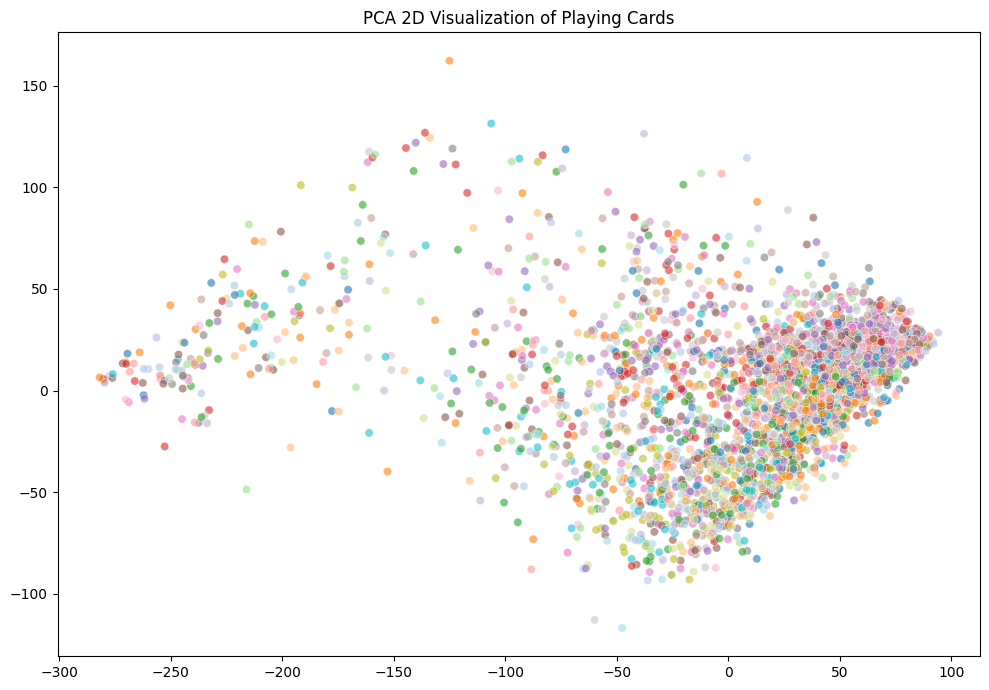

In [26]:
#viasualisasi 2d dengan PCA
x_list, y_list = [], []
images_needed = 3000

for _ in range(images_needed // train_gen.batch_size + 1):
    x_batch, y_batch = next(train_gen)
    x_list.append(x_batch)
    y_list.append(np.argmax(y_batch, axis=1)) 
    
    if len(np.concatenate(x_list)) >= images_needed:
        break

x_train_sample = np.concatenate(x_list)[:images_needed]
y_train_sample = np.concatenate(y_list)[:images_needed]

x_flat = x_train_sample.reshape(len(x_train_sample), -1)

pca_2d = PCA(n_components=2)
x_2d = pca_2d.fit_transform(x_flat)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=x_2d[:,0], 
    y=x_2d[:,1], 
    hue=y_train_sample,
    palette='tab20',
    legend=False,
    alpha=0.6
)

plt.title("PCA 2D Visualization of Playing Cards")
plt.tight_layout()
plt.show()

In [27]:
height, width = x_train_sample.shape[1], x_train_sample.shape[2]

print(f"Dimensi awal (grid): {height}x{width}")
print("Dimensi flatten:", x_flat.shape[1])
print("Dimensi PCA:", x_2d.shape[1])


Dimensi awal (grid): 224x224
Dimensi flatten: 150528
Dimensi PCA: 2


# Downsampling Sederhana

In [28]:
df = df[df['filepaths'].apply(os.path.exists)].reset_index(drop=True)

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['labels'],
    random_state=42
)

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(56, 56),
    interpolation='nearest',
    batch_size=32,
    class_mode='categorical',
)

val_gen = datagen.flow_from_dataframe(
    val_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(56, 56),
    interpolation='nearest',
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
)

Found 6523 validated image filenames belonging to 53 classes.
Found 1631 validated image filenames belonging to 53 classes.


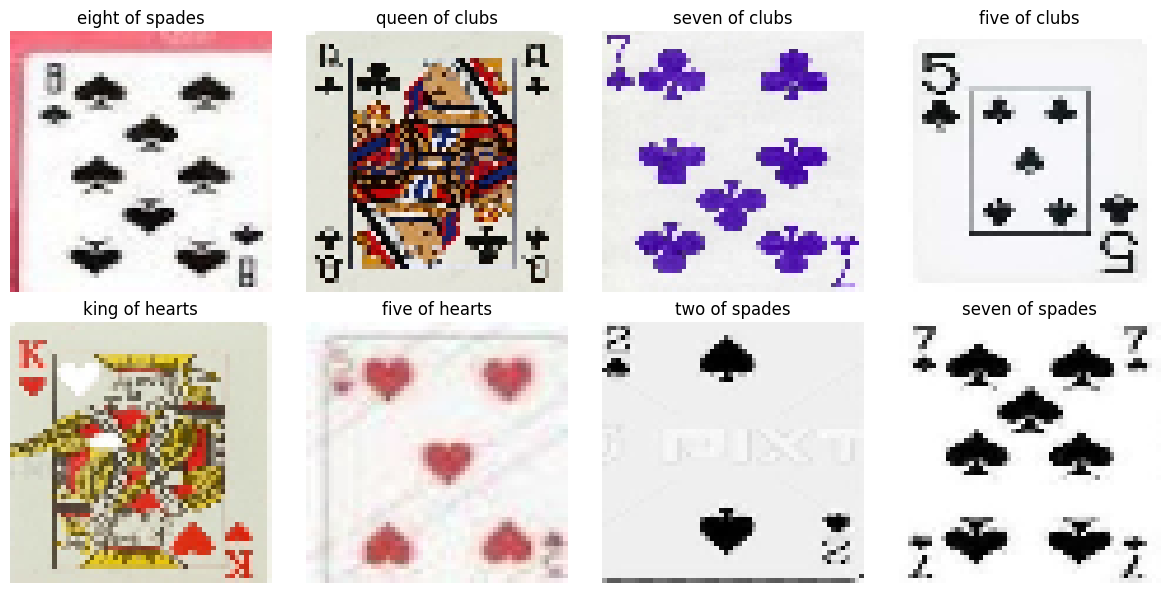

In [32]:
x_batch, y_batch = next(train_gen)

labels = list(train_gen.class_indices.keys())

plt.figure(figsize=(12,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(x_batch[i])
    plt.title(labels[np.argmax(y_batch[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Grafik Distribusi Label

In [30]:
label_counts = df['labels'].value_counts()
print(label_counts)

labels
ace of spades        191
jack of spades       182
ace of hearts        181
jack of clubs        181
jack of hearts       178
seven of spades      175
queen of diamonds    173
queen of spades      172
queen of clubs       171
jack of diamonds     170
eight of diamonds    169
five of spades       168
six of spades        168
ten of spades        168
four of clubs        167
two of hearts        165
two of spades        165
four of hearts       164
nine of spades       164
three of diamonds    163
eight of hearts      162
six of clubs         162
king of spades       161
ten of diamonds      161
five of clubs        160
seven of hearts      153
three of spades      152
ten of clubs         151
four of spades       150
queen of hearts      149
six of diamonds      149
eight of clubs       148
five of diamonds     148
five of hearts       146
eight of spades      145
king of diamonds     145
nine of hearts       143
two of diamonds      143
two of clubs         140
ace of diamonds   

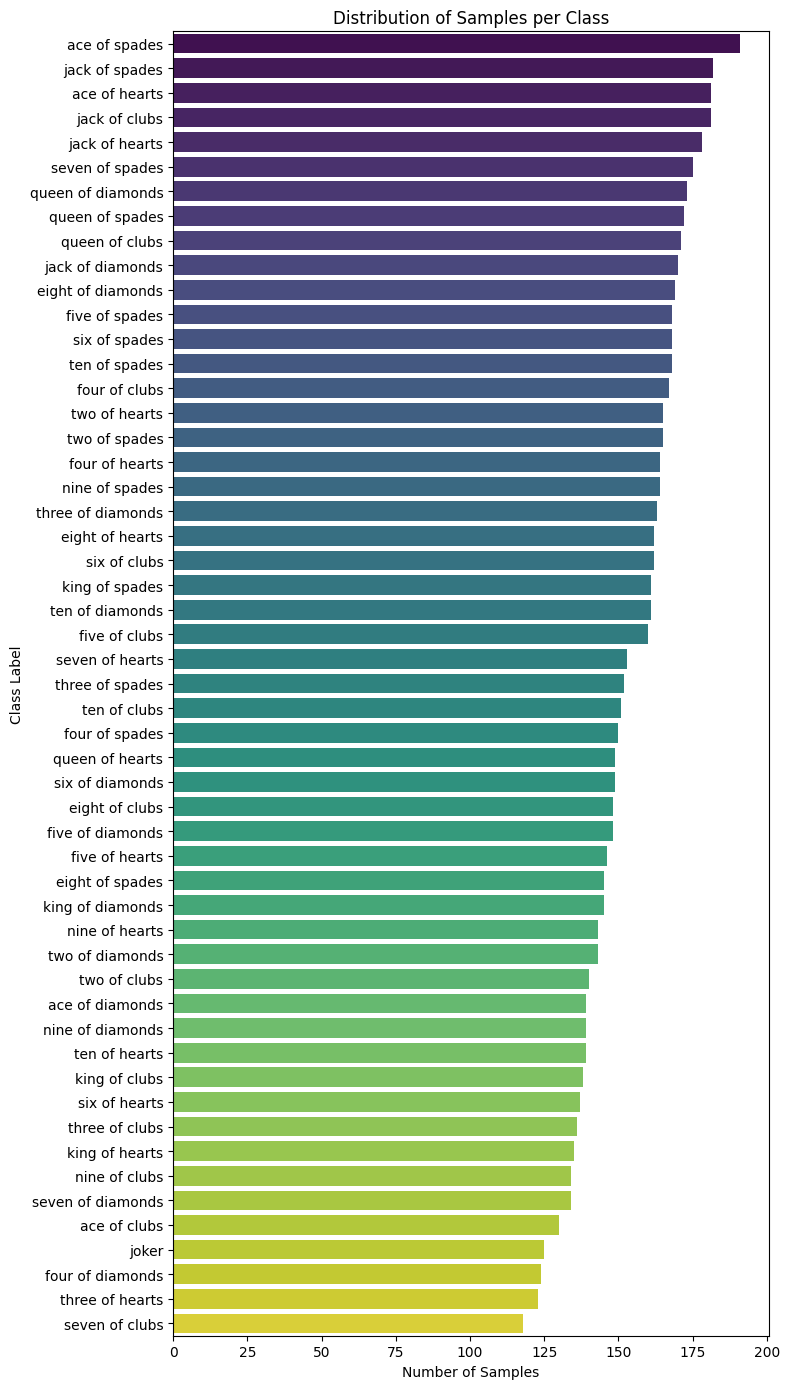

In [31]:
plt.figure(figsize=(8,14))

sns.barplot(
    y=label_counts.index,
    x=label_counts.values,
    palette="viridis",
    hue=label_counts.index,
    legend=False
)

plt.xlabel("Number of Samples")
plt.ylabel("Class Label")
plt.title("Distribution of Samples per Class")

plt.tight_layout()
plt.show()

# Perbandingan Brightness

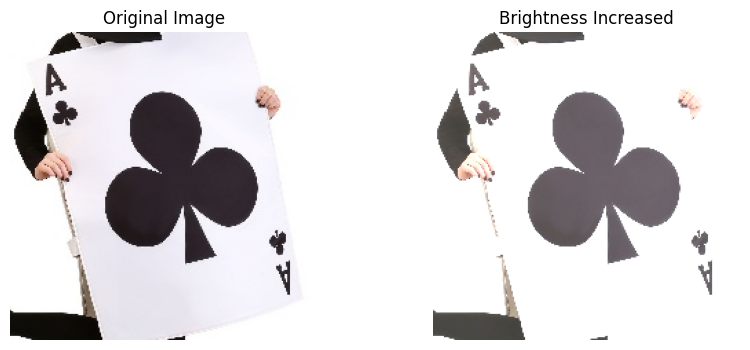

In [36]:
img = cv2.imread(df['filepaths'][0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

bright_img = cv2.convertScaleAbs(img, alpha=1, beta=60)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(bright_img)
plt.title("Brightness Increased")
plt.axis("off")

plt.show()

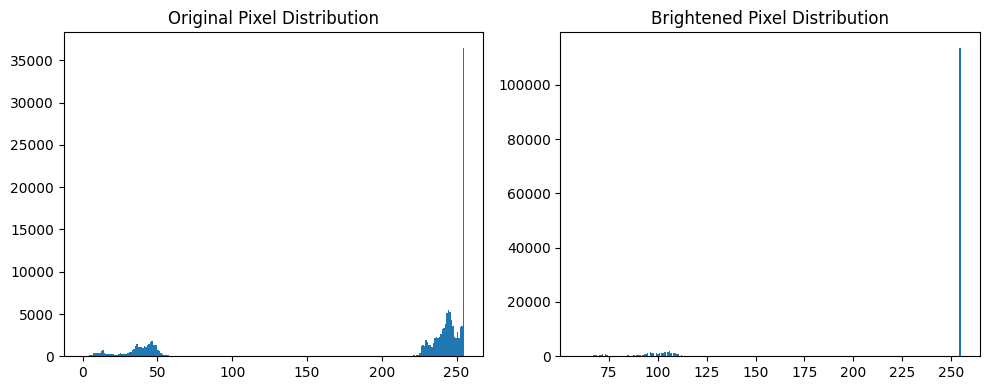

In [37]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(img.ravel(), bins=256)
plt.title("Original Pixel Distribution")

plt.subplot(1,2,2)
plt.hist(bright_img.ravel(), bins=256)
plt.title("Brightened Pixel Distribution")

plt.tight_layout()
plt.show()